Decision Tree Accuracy:
0.9853658536585366

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



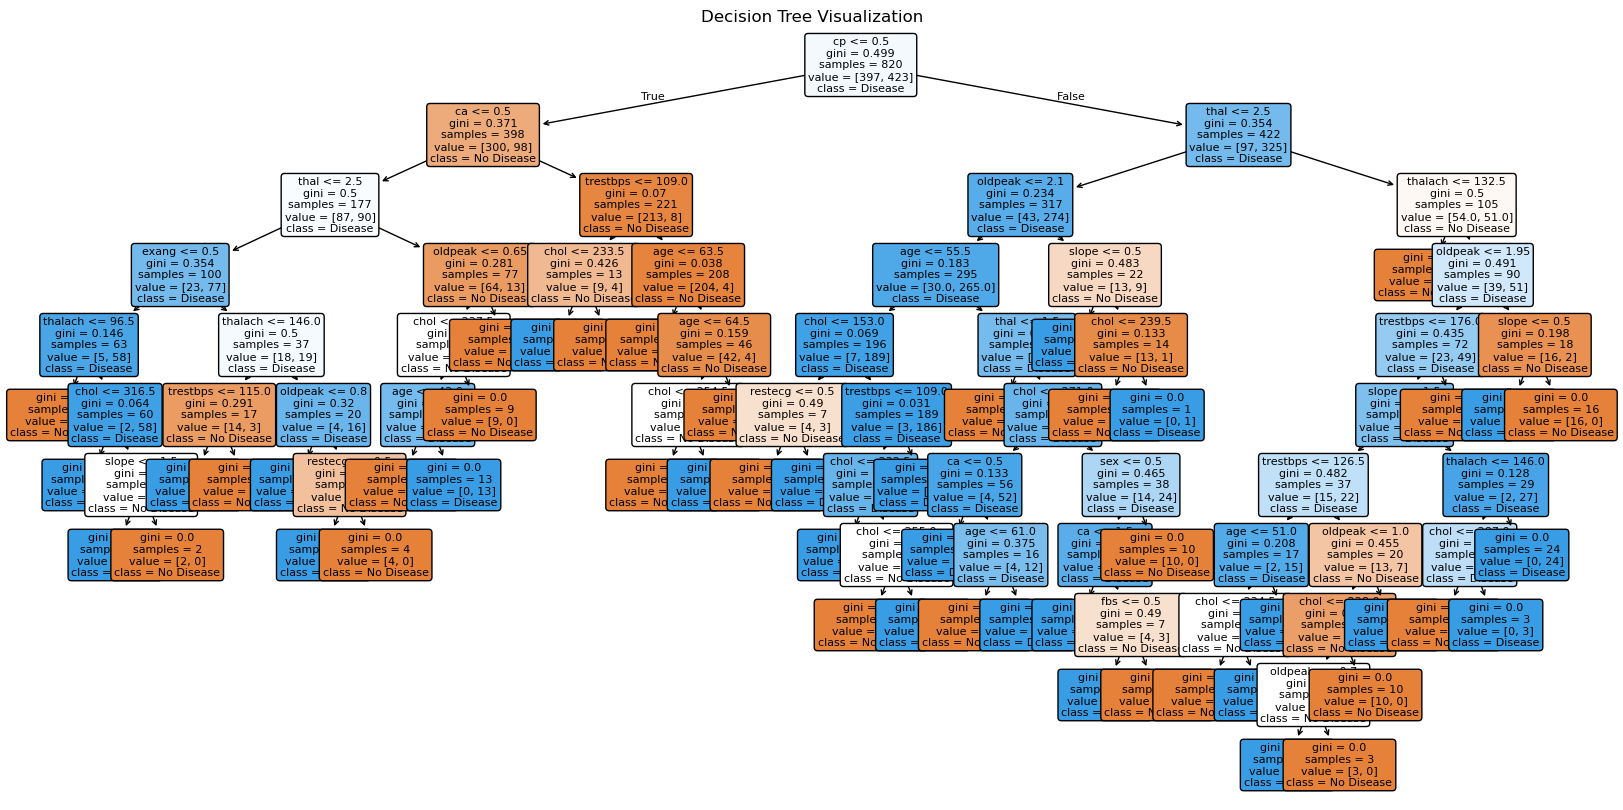


Decision Tree Accuracy (Max Depth = 3):
0.7804878048780488

Random Forest Accuracy:
0.9853658536585366

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Feature Importance:
     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


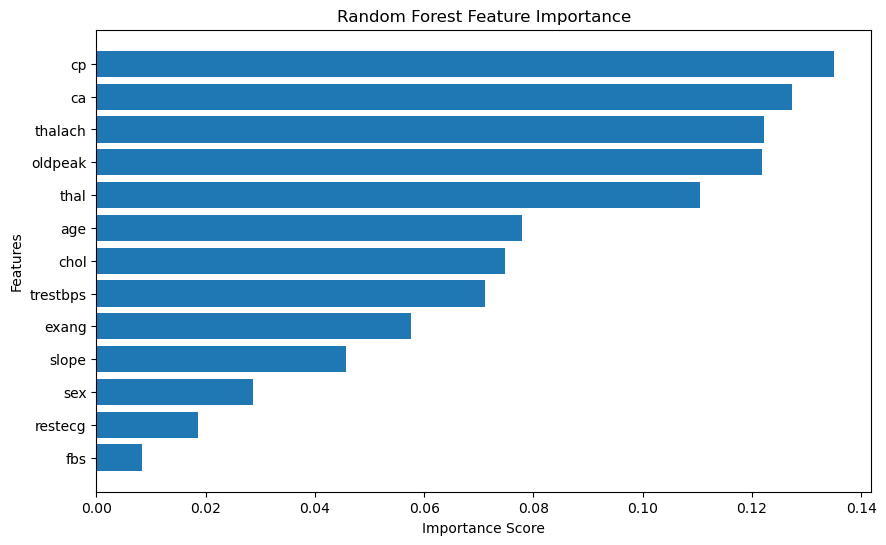


Cross Validation Scores:
[1.         1.         1.         1.         0.98536585]

Mean Cross Validation Accuracy:
0.9970731707317073


In [4]:
# Decision Trees and Random Forests

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
df = pd.read_csv("C:/Users/saran/Downloads/archive (4)/heart.csv")

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ====================================
# Decision Tree Classifier
# ====================================

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Visualize Decision Tree
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

# ====================================
# Overfitting Control (Max Depth)
# ====================================

dt_depth = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_depth.fit(X_train, y_train)

y_pred_depth = dt_depth.predict(X_test)

print("\nDecision Tree Accuracy (Max Depth = 3):")
print(accuracy_score(y_test, y_pred_depth))

# ====================================
# Random Forest Classifier
# ====================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# ====================================
# Feature Importance
# ====================================

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# ====================================
# Cross Validation
# ====================================

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nMean Cross Validation Accuracy:")
print(cv_scores.mean())
